<a href="https://colab.research.google.com/github/riyamotwanii/AML-Assignments/blob/main/Exp_8_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== DATASET HEAD ==========

   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  

========== DATASET INFO ==========

<class 'pandas.core.frame.DataFrame'>


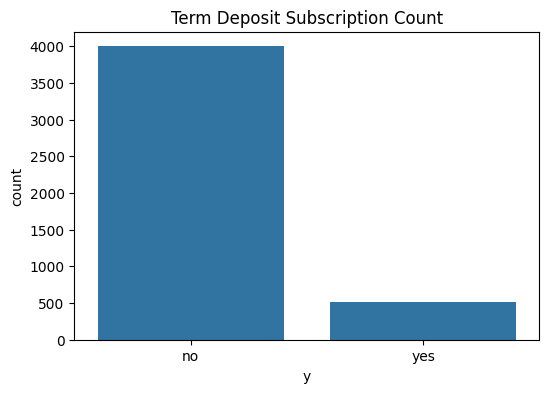

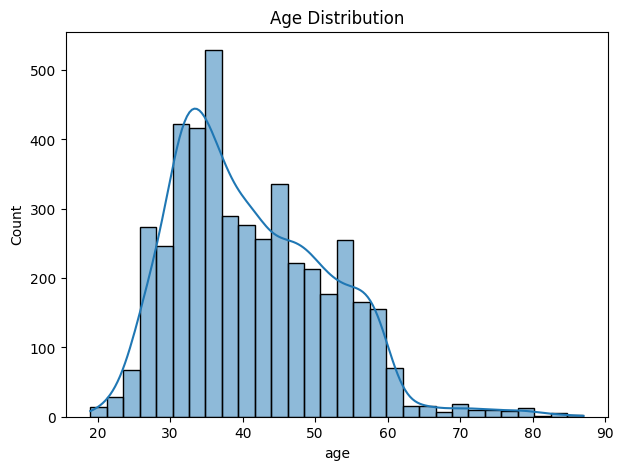

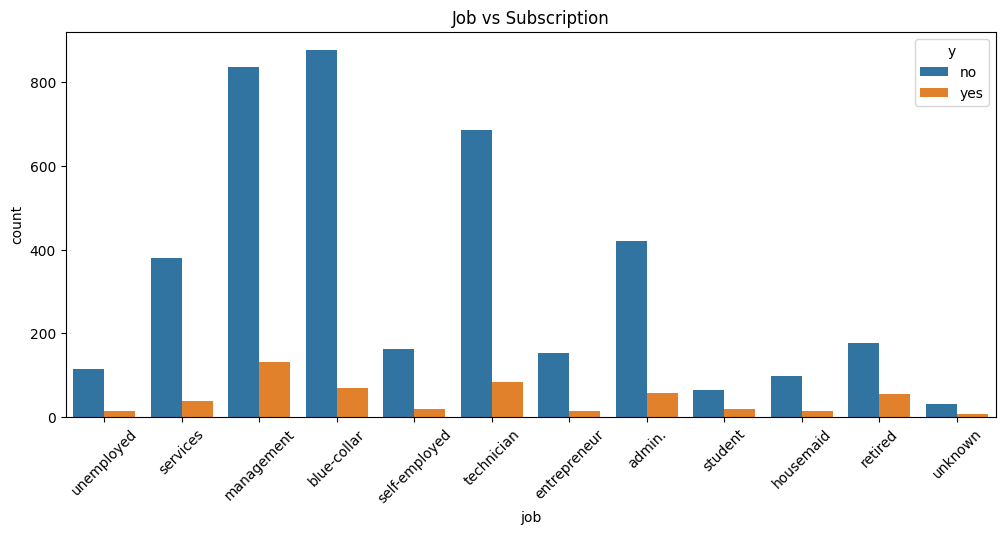


MODEL PERFORMANCE

Accuracy : 88.95 %

Confusion Matrix :

[[781  26]
 [ 74  24]]

Classification Report :

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       807
           1       0.48      0.24      0.32        98

    accuracy                           0.89       905
   macro avg       0.70      0.61      0.63       905
weighted avg       0.87      0.89      0.87       905


========== FEATURE IMPORTANCE ==========

     Feature  Importance
7   duration    0.345979
4    balance    0.172027
0        age    0.155170
9   poutcome    0.081668
1        job    0.072488
8   campaign    0.055897
3  education    0.041891
2    marital    0.034837
5    housing    0.025939
6       loan    0.014105


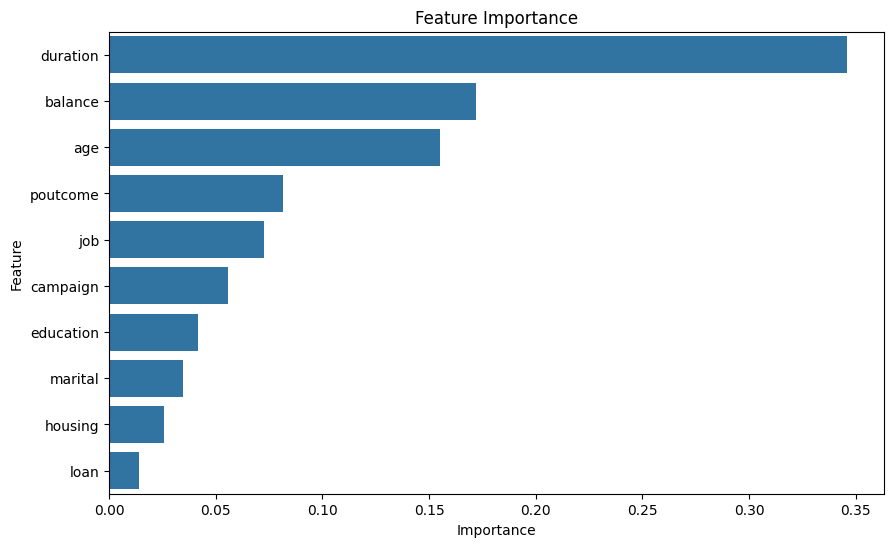


FINAL CONCLUSION

1. Dataset was directly loaded from UCI repository using requests and zipfile.
2. EDA was performed successfully.
3. Important features were selected manually.
4. Random Forest Classifier predicted subscription status.
5. Feature importance identified key influencing factors.


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')



url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"

# Download and extract specific file from ZIP
r = requests.get(url)
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    with z.open('bank.csv') as f:
        df = pd.read_csv(f, sep=';')

print("========== DATASET HEAD ==========\n")
print(df.head())



print("\n========== DATASET INFO ==========\n")
print(df.info())

print("\n========== DATASET SHAPE ==========\n")
print(df.shape)

print("\n========== MISSING VALUES ==========\n")
print(df.isnull().sum())

# ============================================================
# STEP 4 : EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)
plt.title("Term Deposit Subscription Count")
plt.show()

plt.figure(figsize=(7,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(12,5))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.title("Job vs Subscription")
plt.show()

# ============================================================
# STEP 5 : MANUAL FEATURE SELECTION
# ============================================================

selected_features = [
    'age', 'job', 'marital', 'education', 'balance',
    'housing', 'loan', 'duration', 'campaign', 'poutcome'
]

X = df[selected_features]
y = df['y']

# ============================================================
# STEP 6 : ENCODE CATEGORICAL DATA
# ============================================================

label_encoders = {}
for column in X.columns:
    if X[column].dtype == 'object':
        le = LabelEncoder()
        X[column] = le.fit_transform(X[column])
        label_encoders[column] = le

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

# ============================================================
# STEP 7 : FEATURE SCALING
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# STEP 8 : TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ============================================================
# STEP 9 : TRAIN RANDOM FOREST MODEL
# ============================================================

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ============================================================
# STEP 10 : PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

# ============================================================
# STEP 11 : MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
print("\n================================================")
print("MODEL PERFORMANCE")
print("================================================\n")
print("Accuracy :", round(accuracy * 100, 2), "%")
print("\nConfusion Matrix :\n")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report :\n")
print(classification_report(y_test, y_pred))

# ============================================================
# STEP 12 : FEATURE IMPORTANCE
# ============================================================

importance = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\n========== FEATURE IMPORTANCE ==========\n")
print(feature_importance)

# ============================================================
# STEP 13 : FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance")
plt.show()

# ============================================================
# FINAL CONCLUSION
# ============================================================

print("\n================================================")
print("FINAL CONCLUSION")
print("================================================\n")
print("1. Dataset was directly loaded from UCI repository using requests and zipfile.")
print("2. EDA was performed successfully.")
print("3. Important features were selected manually.")
print("4. Random Forest Classifier predicted subscription status.")
print("5. Feature importance identified key influencing factors.")